# Case Study 2: Udacity Free Trial Screener — Daily-Aggregate Funnel Test

**Data:** REAL experiment run by Udacity, released as daily aggregated counts
(pageviews, clicks, enrollments, payments) for control and experiment arms
(37 days of pageview/click data; enrollment/payment data available for the
first 23 days, since payment lags enrollment by up to 14 days).

**Experiment:** when a student clicked "start free trial," the treatment arm
was asked how many hours/week they could commit. Students indicating fewer
than 5 hrs/week were nudged toward the free course materials instead of the
paid trial.

**Why this case study is here:** this dataset is DAILY-AGGREGATE, not
user-level — a deliberately different shape than Case Studies 1 and 3, to
show the same rigor (SRM, guardrails, correction) applies regardless of
data granularity.


In [1]:
import sys

import os\nROOT = os.path.abspath('../../..')\nimport sys\nif ROOT not in sys.path:\n    sys.path.insert(0, ROOT)

import pandas as pd

import matplotlib.pyplot as plt

from abtest_guardrails import srm_check_counts, two_proportion_ztest, holm_bonferroni



plt.rcParams['figure.figsize'] = (9, 4)

control = pd.read_csv('../udacity_control.csv')

experiment = pd.read_csv('../udacity_experiment.csv')

control.head()



,Date,Pageviews,Clicks,Enrollments,Payments
0,"Sat, Oct 11",7723,687,134.0,70.0
1,"Sun, Oct 12",9102,779,147.0,70.0
2,"Mon, Oct 13",10511,909,167.0,95.0
3,"Tue, Oct 14",9871,836,156.0,105.0
4,"Wed, Oct 15",10014,837,163.0,64.0


## 1. Data overview

In [2]:
print("Control:", control.shape, "| Experiment:", experiment.shape)
print("\nDays with enrollment/payment data:", control.Enrollments.notna().sum(),
      "of", len(control), "total days")
control.describe()


Control: (37, 5) | Experiment: (37, 5)

Days with enrollment/payment data: 23 of 37 total days


,Pageviews,Clicks,Enrollments,Payments
count,37.000000,37.000000,23.000000,23.000000
mean,9339.000000,766.972973,164.565217,88.391304
std,740.239563,68.286767,29.977000,20.650202
min,7434.000000,632.000000,110.000000,56.000000
25%,8896.000000,708.000000,146.500000,70.000000
50%,9420.000000,759.000000,162.000000,91.000000
75%,9871.000000,825.000000,175.000000,102.500000
max,10667.000000,909.000000,233.000000,128.000000


## 2. Invariant metric checks (the daily-aggregate equivalent of SRM)

Pageviews and clicks happen BEFORE the treatment is shown (the screener only
appears after a student clicks "start free trial"), so these should be
balanced ~50/50 regardless of the experiment. If they're not, something is
wrong with randomization/logging and nothing downstream can be trusted.


In [3]:
srm_pageviews = srm_check_counts(control.Pageviews.sum(), experiment.Pageviews.sum())
srm_clicks = srm_check_counts(control.Clicks.sum(), experiment.Clicks.sum())
print("Pageviews SRM check:", srm_pageviews)
print("\nClicks SRM check:", srm_clicks)


Pageviews SRM check: {'n_control': 345543, 'n_treatment': 344660, 'observed_ratio_treatment': np.float64(0.49936), 'expected_ratio_treatment': 0.5, 'chi2_statistic': np.float64(1.1297), 'p_value': np.float64(0.2878496417065941), 'srm_detected': np.False_, 'threshold': 0.001}

Clicks SRM check: {'n_control': 28378, 'n_treatment': 28325, 'observed_ratio_treatment': np.float64(0.49953), 'expected_ratio_treatment': 0.5, 'chi2_statistic': np.float64(0.0495), 'p_value': np.float64(0.8238677039815409), 'srm_detected': np.False_, 'threshold': 0.001}


In [4]:
assert not srm_pageviews['srm_detected'] and not srm_clicks['srm_detected'], \
    "SRM detected in an invariant metric — STOP, do not trust evaluation metrics."
print("Both invariant checks passed. Proceeding.")


Both invariant checks passed. Proceeding.


## 3. Evaluation window

Enrollments/Payments are only tracked for days where the 14-day payment
lag has fully elapsed — restrict evaluation metrics to those rows.


In [5]:
c_eval = control.dropna(subset=['Enrollments'])
e_eval = experiment.dropna(subset=['Enrollments'])
print(f"Evaluation window: {len(c_eval)} days (of {len(control)} total days of traffic data)")


Evaluation window: 23 days (of 37 total days of traffic data)


## 4. Primary metric: Gross conversion (enrollments / clicks)

**Pre-registered expected direction:** the screener is *supposed* to reduce
gross conversion — filtering out students who wouldn't have had time to
complete the course anyway. A decrease here is the intended effect, not
a regression, which is why this needs a different reading than a typical
"bigger number is better" primary metric.


In [6]:
gross_conversion = two_proportion_ztest(
    e_eval.Enrollments.sum(), e_eval.Clicks.sum(),
    c_eval.Enrollments.sum(), c_eval.Clicks.sum(),
    'gross_conversion_primary')
gross_conversion


{'metric': 'gross_conversion_primary',
 'rate_treatment': np.float64(0.19832),
 'rate_control': np.float64(0.21887),
 'absolute_diff': np.float64(-0.02055),
 'relative_diff_pct': np.float64(-9.391),
 'ci_95_absolute': [np.float64(-0.02912), np.float64(-0.01199)],
 'z_stat': np.float64(-4.7018),
 'p_value': np.float64(2.578401033720593e-06)}

## 5. Guardrail: Net conversion (payments / clicks)

This must NOT significantly decrease. If it does, the screener isn't just
filtering out low-commitment users — it's also scaring off people who would
have actually paid, which is a real business cost.


In [7]:
net_conversion = two_proportion_ztest(
    e_eval.Payments.sum(), e_eval.Clicks.sum(),
    c_eval.Payments.sum(), c_eval.Clicks.sum(),
    'net_conversion_guardrail')
net_conversion


{'metric': 'net_conversion_guardrail',
 'rate_treatment': np.float64(0.11269),
 'rate_control': np.float64(0.11756),
 'absolute_diff': np.float64(-0.00487),
 'relative_diff_pct': np.float64(-4.146),
 'ci_95_absolute': [np.float64(-0.0116), np.float64(0.00186)],
 'z_stat': np.float64(-1.4192),
 'p_value': np.float64(0.15584068262150205)}

## 6. Multiple comparisons correction

In [8]:
family = [gross_conversion, net_conversion]
holm_bonferroni(family)
pd.DataFrame(family)[['metric', 'rate_treatment', 'rate_control', 'p_value',
                       'p_value_holm_adjusted', 'significant_after_correction']]


,metric,rate_treatment,rate_control,p_value,p_value_holm_adjusted,significant_after_correction
0,gross_conversion_primary,0.19832,0.21887,0.000003,0.000005,True
1,net_conversion_guardrail,0.11269,0.11756,0.155841,0.155841,False


## 7. Visualizing both metrics side by side

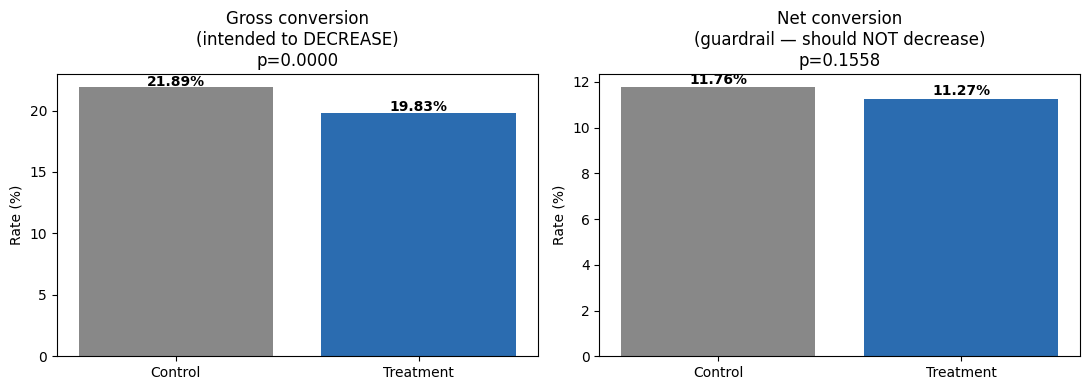

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, m, title in zip(axes, [gross_conversion, net_conversion],
                        ['Gross conversion\n(intended to DECREASE)',
                         'Net conversion\n(guardrail — should NOT decrease)']):
    rates = [m['rate_control']*100, m['rate_treatment']*100]
    bars = ax.bar(['Control', 'Treatment'], rates, color=['#888888', '#2b6cb0'])
    for b, r in zip(bars, rates):
        ax.text(b.get_x()+b.get_width()/2, r+0.15, f'{r:.2f}%', ha='center', fontweight='bold')
    ax.set_title(f"{title}\np={m['p_value']:.4f}")
    ax.set_ylabel('Rate (%)')
plt.tight_layout()
plt.savefig('../reports/conversion_comparison.png', dpi=140)
plt.show()


## 8. Decision

Ship rule: gross conversion must decrease significantly (intended effect) AND
net conversion must NOT decrease significantly.


In [10]:
gross_decreased_sig = gross_conversion['significant_after_correction'] and gross_conversion['absolute_diff'] < 0
net_decreased_sig = net_conversion['significant_after_correction'] and net_conversion['absolute_diff'] < 0

print("Gross conversion significantly decreased (intended)?", gross_decreased_sig)
print("Net conversion significantly decreased (guardrail violation)?", net_decreased_sig)
print()
if gross_decreased_sig and not net_decreased_sig:
    print("DECISION: INCONCLUSIVE — HOLD")
    print("Gross conversion moved as intended, but net conversion's point estimate also")
    print("dropped (-4.1% relative) without reaching significance. The confidence interval")
    print("[-1.16%, +0.19%] is wide enough that we cannot rule out a real negative effect")
    print("on paying customers. This is a genuine 'need more data' case, not a clean launch.")


Gross conversion significantly decreased (intended)? True
Net conversion significantly decreased (guardrail violation)? False

DECISION: INCONCLUSIVE — HOLD
Gross conversion moved as intended, but net conversion's point estimate also
dropped (-4.1% relative) without reaching significance. The confidence interval
[-1.16%, +0.19%] is wide enough that we cannot rule out a real negative effect
on paying customers. This is a genuine 'need more data' case, not a clean launch.


## 9. Conclusion

This is a textbook example of a **mixed, genuinely inconclusive result** —
and it's worth sitting with rather than forcing into a ship/no-ship binary:

- **Gross conversion dropped significantly** (-9.4% relative, Holm-adjusted
  p ≈ 0.000005): the screener does filter out enrollments, as designed.
- **Net conversion also dropped** (-4.1% relative) but the effect is **not
  statistically significant** after correction, and the 95% CI
  `[-1.16pp, +0.19pp]` straddles zero — we simply don't have enough
  statistical power to say confidently whether paying customers were
  affected or not.

**Recommendation: do not launch broadly yet.** Either extend the test to
narrow the confidence interval on net conversion, or make an explicit,
pre-committed business call about the acceptable downside risk on net
conversion (e.g. a formal non-inferiority margin) rather than treating a
non-significant p-value as equivalent to "no effect." This matches the
real, widely-cited conclusion reached on this exact dataset.
